In [3]:
import os, time, json, subprocess, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

PROJECT = '/content/Group_7_ECG_Project'
for sub in ['models', 'results', 'graphs']:
    os.makedirs(f'{PROJECT}/{sub}', exist_ok=True)
print('TensorFlow', tf.__version__)

TensorFlow 2.20.0


In [4]:
def sh(cmd):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=30).stdout.strip() or 'N/A'
    except Exception as e:
        return f'N/A ({e})'

gpus = tf.config.list_physical_devices('GPU')
build = tf.sysconfig.get_build_info()
hardware_info = {
    'recorded_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    'python': platform.python_version(),
    'tensorflow': tf.__version__,
    'keras': keras.__version__,
    'gpu_detected': len(gpus) > 0,
    'gpu_name': sh("nvidia-smi --query-gpu=name --format=csv,noheader"),
    'gpu_memory': sh("nvidia-smi --query-gpu=memory.total --format=csv,noheader"),
    'nvidia_driver': sh("nvidia-smi --query-gpu=driver_version --format=csv,noheader"),
    'cuda_build': str(build.get('cuda_version', 'N/A')),
    'cudnn_build': str(build.get('cudnn_version', 'N/A')),
    'cpu_model': sh("lscpu | grep 'Model name' | sed 's/.*: *//'"),
    'cpu_logical_cores': os.cpu_count(),
    'ram': sh("grep MemTotal /proc/meminfo"),
}
for k, v in hardware_info.items():
    print(f'{k:20s}: {v}')

RUN_GPU = len(gpus) > 0
if not RUN_GPU:
    print('\n!!! GPU paoa jayni. Runtime > Change runtime type > GPU select kore abar Run all koro. !!!')

with open(f'{PROJECT}/results/hardware_info_v1.json', 'w') as f:
    json.dump(hardware_info, f, indent=2)

recorded_at         : 2026-10-04 15:08:15
python              : 3.13.15
tensorflow          : 2.20.0
keras               : 3.13.2
gpu_detected        : True
gpu_name            : Tesla T4
gpu_memory          : 15360 MiB
nvidia_driver       : 580.82.07
cuda_build          : 12.5.1
cudnn_build         : 9
cpu_model           : Intel(R) Xeon(R) CPU @ 2.00GHz
cpu_logical_cores   : 2
ram                 : MemTotal:       13286944 kB


In [5]:
!pip -q install gdown
import gdown
if not os.path.exists('ecg_processed_v1.npz'):
    gdown.download(id='1TO043QL8KSBiMkkf4Di5MMbLF5wXGgT0', output='ecg_processed_v1.npz', quiet=False)
# Jodi gdown fail kore: Drive theke file download kore Colab-er left sidebar (Files) e upload koro.

d = np.load('ecg_processed_v1.npz')
X_train, y_train = d['X_train'], d['y_train']
X_val,   y_val   = d['X_val'],   d['y_val']
X_test,  y_test  = d['X_test'],  d['y_test']

expected = {'X_train': (68386, 360, 1), 'X_val': (16399, 360, 1), 'X_test': (15897, 360, 1)}
for name, shape in expected.items():
    assert d[name].shape == shape, f'{name} shape mismatch: {d[name].shape} != {shape}'
print('Shapes OK')
for n, y in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'{n:5s}: normal={np.sum(y==0):6d}  abnormal={np.sum(y==1):5d}  abnormal%={100*np.mean(y):.1f}')

Shapes OK
train: normal= 62790  abnormal= 5596  abnormal%=8.2
val  : normal= 14553  abnormal= 1846  abnormal%=11.3
test : normal= 12733  abnormal= 3164  abnormal%=19.9


In [6]:
SEED          = 42      # same seed => same initial weights & same data shuffle order
BATCH_SIZE    = 128
LEARNING_RATE = 1e-3    # Adam
MAIN_EPOCHS   = 15      # Experiment A max epochs (early stopping on val_loss, patience 4)
TIMING_EPOCHS = 5       # Experiment B: CPU & GPU dutoi exactly eto-i epoch chalabe (no early stopping)
TIMING_REPEATS = 1      # CPU slow hole 1 e rakho. Time thakle 3 koro, average nibe
THRESHOLD     = 0.5     # prob >= 0.5 => abnormal

# Imbalance (train-e abnormal matro 8.2%) tai class weight
n = len(y_train); n0 = int(np.sum(y_train == 0)); n1 = int(np.sum(y_train == 1))
class_weight = {0: n / (2 * n0), 1: n / (2 * n1)}
print('class_weight:', class_weight)

settings = dict(SEED=SEED, BATCH_SIZE=BATCH_SIZE, LEARNING_RATE=LEARNING_RATE, optimizer='Adam',
                loss='binary_crossentropy', MAIN_EPOCHS=MAIN_EPOCHS, TIMING_EPOCHS=TIMING_EPOCHS,
                TIMING_REPEATS=TIMING_REPEATS, THRESHOLD=THRESHOLD, class_weight=class_weight,
                precision='float32 (no mixed precision)', data='ecg_processed_v1.npz')
with open(f'{PROJECT}/results/cnn_lstm_experiment_settings_v1.json', 'w') as f:
    json.dump(settings, f, indent=2)

class_weight: {0: 0.5445612358655837, 1: 6.110257326661902}


In [7]:
def build_cnn_lstm():
    inp = keras.Input(shape=(360, 1))
    x = layers.Conv1D(32, 5, padding='same', activation='relu')(inp)
    x = layers.MaxPooling1D(2)(x)                     # 360 -> 180
    x = layers.Conv1D(64, 5, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)                     # 180 -> 90
    x = layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling1D(2)(x)                     # 90 -> 45 time-steps
    x = layers.LSTM(64)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inp, out, name='cnn_lstm')
    model.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

build_cnn_lstm().summary()

Model: "cnn_lstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 360, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 360, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 180, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 180, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 90, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,721 (338.75 KB)

 Trainable params: 86,721 (338.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
class EpochTimer(keras.callbacks.Callback):
    # per-epoch wall-clock time (validation shoho; CPU ar GPU dutoi-te same jinis measure hoy)
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self.t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.perf_counter() - self.t0)

def run_training(device, epochs, early_stop=False):
    keras.backend.clear_session()
    keras.utils.set_random_seed(SEED)
    with tf.device(device):
        print('Device scope:', device, '| tensor placed on:', tf.constant(1.0).device)
        model = build_cnn_lstm()
        timer = EpochTimer()
        cbs = [timer]
        if early_stop:
            cbs.append(keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True))
        t0 = time.perf_counter()
        hist = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                         epochs=epochs, batch_size=BATCH_SIZE, class_weight=class_weight,
                         shuffle=True, callbacks=cbs, verbose=2)
        total = time.perf_counter() - t0
    return model, hist, timer.times, total

def predict_probs(model, X, device, batch_size=256):
    with tf.device(device):
        return model.predict(X, batch_size=batch_size, verbose=0).ravel()

def compute_metrics(y_true, prob):
    pred = (prob >= THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return dict(accuracy=accuracy_score(y_true, pred),
                precision=precision_score(y_true, pred, zero_division=0),
                recall=recall_score(y_true, pred, zero_division=0),
                f1=f1_score(y_true, pred, zero_division=0),
                specificity=tn / (tn + fp), roc_auc=roc_auc_score(y_true, prob),
                TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))

def time_inference(model, X, device, repeats=3, batch_size=256):
    # 1 bar warm-up (graph build / GPU init) tarpor 'repeats' bar full test set predict, average
    with tf.device(device):
        model.predict(X[:batch_size * 2], batch_size=batch_size, verbose=0)
        ts = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            model.predict(X, batch_size=batch_size, verbose=0)
            ts.append(time.perf_counter() - t0)
    mean_t = float(np.mean(ts))
    return mean_t, 1000 * mean_t / len(X)

In [9]:
main_device = '/GPU:0' if RUN_GPU else '/CPU:0'
model, hist, ep_times, total_time = run_training(main_device, MAIN_EPOCHS, early_stop=True)

prob_test = predict_probs(model, X_test, main_device)
test_m = compute_metrics(y_test, prob_test)
prob_val = predict_probs(model, X_val, main_device)
val_m = compute_metrics(y_val, prob_val)

epochs_run = len(ep_times)
main_row = {'model': 'CNN-LSTM', 'device': main_device, 'epochs_run': epochs_run,
            'train_time_s': round(total_time, 2), 'avg_epoch_time_s': round(float(np.mean(ep_times)), 2),
            **{f'test_{k}': (round(v, 4) if isinstance(v, float) else v) for k, v in test_m.items()},
            **{f'val_{k}': round(v, 4) for k, v in val_m.items() if isinstance(v, float)}}
pd.DataFrame([main_row]).to_csv(f'{PROJECT}/results/cnn_lstm_metrics_v1.csv', index=False)
pd.DataFrame(hist.history).to_csv(f'{PROJECT}/results/cnn_lstm_history_v1.csv', index=False)
model.save(f'{PROJECT}/models/cnn_lstm_v1.keras')

print(f'\nEpochs run: {epochs_run} | total train time: {total_time:.1f}s')
print('TEST metrics:')
for k, v in test_m.items():
    print(f'  {k:12s}: {v:.4f}' if isinstance(v, float) else f'  {k:12s}: {v}')

Device scope: /GPU:0 | tensor placed on: /job:localhost/replica:0/task:0/device:GPU:0
Epoch 1/15
535/535 - 24s - 46ms/step - accuracy: 0.9253 - loss: 0.2553 - val_accuracy: 0.7009 - val_loss: 0.6919
Epoch 2/15
535/535 - 6s - 11ms/step - accuracy: 0.9616 - loss: 0.1397 - val_accuracy: 0.7239 - val_loss: 0.7087
Epoch 3/15
535/535 - 6s - 12ms/step - accuracy: 0.9686 - loss: 0.1134 - val_accuracy: 0.7573 - val_loss: 0.7424
Epoch 4/15
535/535 - 11s - 20ms/step - accuracy: 0.9746 - loss: 0.0946 - val_accuracy: 0.7536 - val_loss: 0.8021
Epoch 5/15
535/535 - 6s - 11ms/step - accuracy: 0.9764 - loss: 0.0807 - val_accuracy: 0.7825 - val_loss: 0.6494
Epoch 6/15
535/535 - 6s - 12ms/step - accuracy: 0.9788 - loss: 0.0692 - val_accuracy: 0.8074 - val_loss: 0.6882
Epoch 7/15
535/535 - 6s - 12ms/step - accuracy: 0.9803 - loss: 0.0663 - val_accuracy: 0.8473 - val_loss: 0.6015
Epoch 8/15
535/535 - 6s - 12ms/step - accuracy: 0.9806 - loss: 0.0625 - val_accuracy: 0.8290 - val_loss: 0.6283
Epoch 9/15
535/5

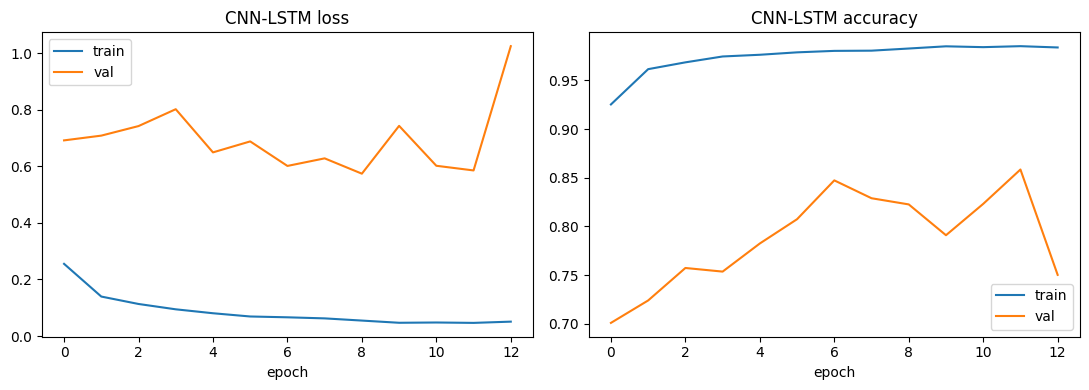

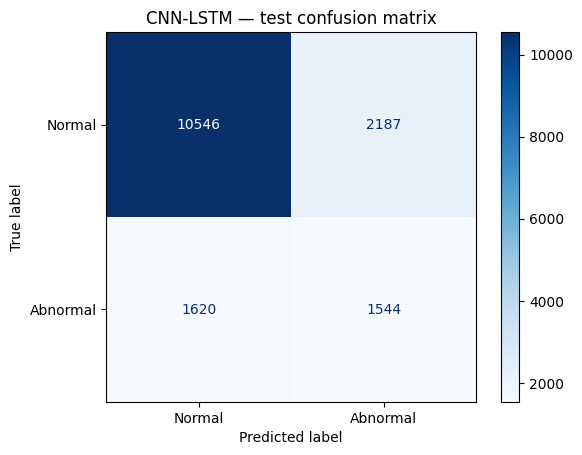

In [10]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('CNN-LSTM loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist.history['accuracy'], label='train'); ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('CNN-LSTM accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.savefig(f'{PROJECT}/graphs/cnn_lstm_training_curves_v1.png', dpi=150); plt.show()

# Confusion matrix (test)
cm = confusion_matrix(y_test, (prob_test >= THRESHOLD).astype(int))
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Abnormal']).plot(cmap='Blues', values_format='d')
plt.title('CNN-LSTM — test confusion matrix')
plt.savefig(f'{PROJECT}/graphs/cnn_lstm_confusion_matrix_v1.png', dpi=150, bbox_inches='tight'); plt.show()

In [11]:
rows = []
devices = (['/GPU:0'] if RUN_GPU else []) + ['/CPU:0']
for device in devices:
    for r in range(TIMING_REPEATS):
        print(f'\n===== {device} | repeat {r+1}/{TIMING_REPEATS} =====')
        m, h, ep_t, tot = run_training(device, TIMING_EPOCHS, early_stop=False)
        inf_total, inf_per_beat_ms = time_inference(m, X_test, device)
        tm = compute_metrics(y_test, predict_probs(m, X_test, device))
        rows.append({'device': 'GPU' if 'GPU' in device else 'CPU', 'repeat': r + 1,
                     'epochs': TIMING_EPOCHS, 'train_time_total_s': tot,
                     'epoch1_s': ep_t[0],
                     'steady_epoch_avg_s': float(np.mean(ep_t[1:])) if len(ep_t) > 1 else float('nan'),
                     'inference_test_set_s': inf_total, 'inference_ms_per_beat': inf_per_beat_ms,
                     'test_accuracy': tm['accuracy'], 'test_precision': tm['precision'],
                     'test_recall': tm['recall'], 'test_f1': tm['f1']})
timing_raw = pd.DataFrame(rows)
timing_raw.to_csv(f'{PROJECT}/results/cnn_lstm_timing_raw_v1.csv', index=False)
timing_raw.round(4)


===== /GPU:0 | repeat 1/1 =====
Device scope: /GPU:0 | tensor placed on: /job:localhost/replica:0/task:0/device:GPU:0
Epoch 1/5
535/535 - 9s - 16ms/step - accuracy: 0.9278 - loss: 0.2542 - val_accuracy: 0.6431 - val_loss: 0.7907
Epoch 2/5
535/535 - 6s - 12ms/step - accuracy: 0.9635 - loss: 0.1423 - val_accuracy: 0.7203 - val_loss: 0.5870
Epoch 3/5
535/535 - 6s - 12ms/step - accuracy: 0.9679 - loss: 0.1113 - val_accuracy: 0.7499 - val_loss: 0.5601
Epoch 4/5
535/535 - 6s - 11ms/step - accuracy: 0.9745 - loss: 0.0876 - val_accuracy: 0.8613 - val_loss: 0.4199
Epoch 5/5
535/535 - 6s - 12ms/step - accuracy: 0.9783 - loss: 0.0743 - val_accuracy: 0.8541 - val_loss: 0.4699

===== /CPU:0 | repeat 1/1 =====
Device scope: /CPU:0 | tensor placed on: /job:localhost/replica:0/task:0/device:CPU:0
Epoch 1/5
535/535 - 54s - 102ms/step - accuracy: 0.9212 - loss: 0.2591 - val_accuracy: 0.8774 - val_loss: 0.4096
Epoch 2/5
535/535 - 52s - 97ms/step - accuracy: 0.9608 - loss: 0.1418 - val_accuracy: 0.6810 -

,device,repeat,epochs,train_time_total_s,epoch1_s,steady_epoch_avg_s,inference_test_set_s,inference_ms_per_beat,test_accuracy,test_precision,test_recall,test_f1
0,GPU,1,5,33.9403,8.7968,6.2177,0.4793,0.0302,0.7671,0.4294,0.5180,0.4696
1,CPU,1,5,297.2005,54.4685,60.6356,3.5626,0.2241,0.7632,0.4219,0.5133,0.4631


,epochs,train_time_total_s,epoch1_s,steady_epoch_avg_s,inference_test_set_s,inference_ms_per_beat,test_accuracy,test_precision,test_recall,test_f1,batch_size,n_train_samples,n_test_samples
device,,,,,,,,,,,,,
CPU,5.0,297.2005,54.4685,60.6356,3.5626,0.2241,0.7632,0.4219,0.5133,0.4631,128,68386,15897
GPU,5.0,33.9403,8.7968,6.2177,0.4793,0.0302,0.7671,0.4294,0.5180,0.4696,128,68386,15897


Speedup (CPU time / GPU time): total training = 8.76x | steady epoch = 9.75x | inference = 7.43x


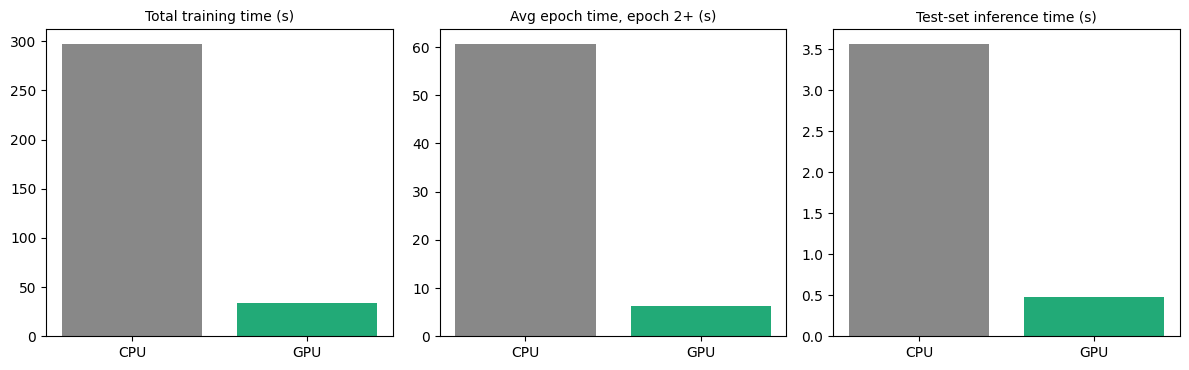

In [12]:
# Summary table (CPU vs GPU) — Member 5 ei table-i report-e boshabe
summary = timing_raw.groupby('device').mean(numeric_only=True).drop(columns='repeat')
summary = summary.reindex([x for x in ['CPU', 'GPU'] if x in summary.index])
summary['batch_size'] = BATCH_SIZE
summary['n_train_samples'] = len(X_train)
summary['n_test_samples'] = len(X_test)
summary.round(4).to_csv(f'{PROJECT}/results/cnn_lstm_cpu_gpu_timing_v1.csv')
display(summary.round(4))

if 'GPU' in summary.index and 'CPU' in summary.index:
    sp_train = summary.loc['CPU', 'train_time_total_s'] / summary.loc['GPU', 'train_time_total_s']
    sp_epoch = summary.loc['CPU', 'steady_epoch_avg_s'] / summary.loc['GPU', 'steady_epoch_avg_s']
    sp_inf   = summary.loc['CPU', 'inference_test_set_s'] / summary.loc['GPU', 'inference_test_set_s']
    print(f'Speedup (CPU time / GPU time): total training = {sp_train:.2f}x | steady epoch = {sp_epoch:.2f}x | inference = {sp_inf:.2f}x')

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.8))
    for a, col, title in zip(ax, ['train_time_total_s', 'steady_epoch_avg_s', 'inference_test_set_s'],
                             ['Total training time (s)', 'Avg epoch time, epoch 2+ (s)', 'Test-set inference time (s)']):
        a.bar(['CPU', 'GPU'], [summary.loc['CPU', col], summary.loc['GPU', col]], color=['#888', '#2a7'])
        a.set_title(title, fontsize=10)
    plt.tight_layout(); plt.savefig(f'{PROJECT}/graphs/cnn_lstm_cpu_vs_gpu_v1.png', dpi=150); plt.show()

In [13]:
import shutil
shutil.make_archive('/content/member4_cnn_lstm_outputs_v1', 'zip', PROJECT)
try:
    from google.colab import files
    files.download('/content/member4_cnn_lstm_outputs_v1.zip')
except Exception as e:
    print('Auto download hoyni, Files sidebar theke zip ta download koro.', e)

print('\nSaved files:')
for root, _, fs in os.walk(PROJECT):
    for f in fs:
        print(' ', os.path.join(root, f).replace(PROJECT + '/', ''))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Saved files:
  results/cnn_lstm_metrics_v1.csv
  results/cnn_lstm_cpu_gpu_timing_v1.csv
  results/cnn_lstm_timing_raw_v1.csv
  results/cnn_lstm_history_v1.csv
  results/hardware_info_v1.json
  results/cnn_lstm_experiment_settings_v1.json
  models/cnn_lstm_v1.keras
  graphs/cnn_lstm_cpu_vs_gpu_v1.png
  graphs/cnn_lstm_confusion_matrix_v1.png
  graphs/cnn_lstm_training_curves_v1.png
